In [136]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [137]:
df=pd.DataFrame()

In [138]:
df['x1']=[1,4,2,6,7,5,5,8,0,4]
df['x2']=[3,2,6,7,2,8,9,1,4,0]
df['label']=[1,1,0,0,0,1,0,1,1,0]

In [139]:
df

,x1,x2,label
0,1,3,1
1,4,2,1
2,2,6,0
3,6,7,0
4,7,2,0
5,5,8,1
6,5,9,0
7,8,1,1
8,0,4,1
9,4,0,0


<Axes: xlabel='x1', ylabel='x2'>

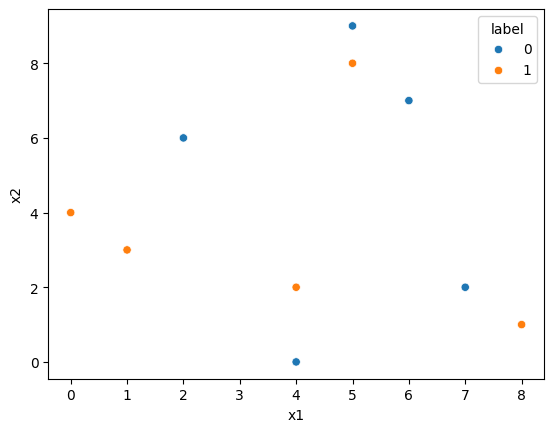

In [140]:
import seaborn as sns
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [141]:
df['weights']=1/df.shape[0]   # 0.1

In [142]:
df

,x1,x2,label,weights
0,1,3,1,0.1
1,4,2,1,0.1
2,2,6,0,0.1
3,6,7,0,0.1
4,7,2,0,0.1
5,5,8,1,0.1
6,5,9,0,0.1
7,8,1,1,0.1
8,0,4,1,0.1
9,4,0,0,0.1


In [143]:
from sklearn.tree import DecisionTreeClassifier

In [144]:
dt=DecisionTreeClassifier(max_depth=1)  # decision stumps becuz of depth =1


In [145]:

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [146]:

# Step 2 - Train 1st model
dt.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [147]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[0] <= 1.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

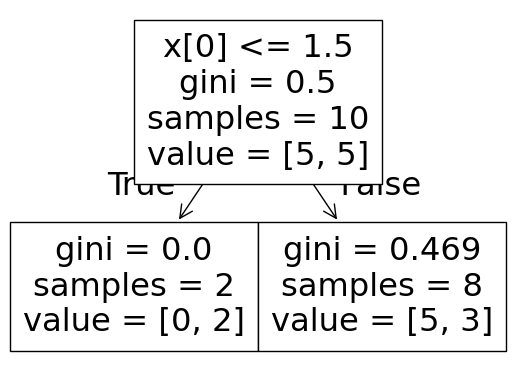

In [148]:
plot_tree(dt)

<Axes: >

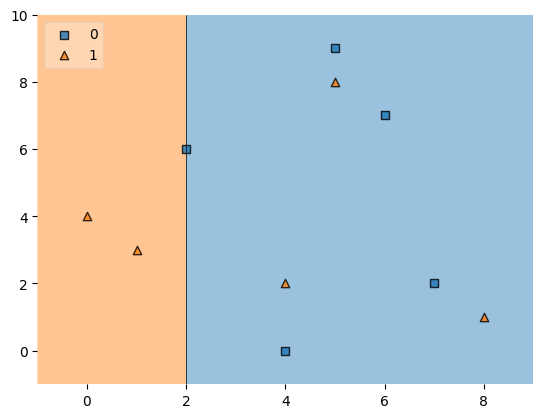

In [149]:
plot_decision_regions(X,y,clf=dt,legend=2)

In [150]:
df['y_pred'] = dt.predict(X)

In [151]:
df

,x1,x2,label,weights,y_pred
0,1,3,1,0.1,1
1,4,2,1,0.1,0
2,2,6,0,0.1,0
3,6,7,0,0.1,0
4,7,2,0,0.1,0
5,5,8,1,0.1,0
6,5,9,0,0.1,0
7,8,1,1,0.1,0
8,0,4,1,0.1,1
9,4,0,0,0.1,0


In [152]:
def calculate_model_weight(error): # error is the sum of the weights of the missclassified points here are three misclasified points  0.1+0.1+0.1
    return 0.5*np.log((1-error)/error+0.00000000001)

In [153]:
# step 3 calculate weight
alpha1=calculate_model_weight(0.3)
alpha1

np.float64(0.4236489301957447)

In [154]:
def update_row_weights(row,alpha=alpah1):
    if(row['label']==row['y_pred']):  # correctly classified so weight decrease
        return row['weights']*np.exp(-alpha)
    else:     # misclassifed so weight increase
        return row['weights']*np.exp(alpha)

In [155]:
df['updated_weights']=df.apply(update_row_weights,axis=1)

In [156]:
df

,x1,x2,label,weights,y_pred,updated_weights
0,1,3,1,0.1,1,0.065465
1,4,2,1,0.1,0,0.152753
2,2,6,0,0.1,0,0.065465
3,6,7,0,0.1,0,0.065465
4,7,2,0,0.1,0,0.065465
5,5,8,1,0.1,0,0.152753
6,5,9,0,0.1,0,0.065465
7,8,1,1,0.1,0,0.152753
8,0,4,1,0.1,1,0.065465
9,4,0,0,0.1,0,0.065465


In [157]:
df['updated_weights'].sum()

np.float64(0.916515138991168)

In [158]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [159]:
df

,x1,x2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,3,1,0.1,1,0.065465,0.071429
1,4,2,1,0.1,0,0.152753,0.166667
2,2,6,0,0.1,0,0.065465,0.071429
3,6,7,0,0.1,0,0.065465,0.071429
4,7,2,0,0.1,0,0.065465,0.071429
5,5,8,1,0.1,0,0.152753,0.166667
6,5,9,0,0.1,0,0.065465,0.071429
7,8,1,1,0.1,0,0.152753,0.166667
8,0,4,1,0.1,1,0.065465,0.071429
9,4,0,0,0.1,0,0.065465,0.071429


In [160]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [161]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

In [162]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [163]:
df[['x1','x2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,3,1,0.1,1,0.065465,0.000000,0.071429
1,4,2,1,0.1,0,0.152753,0.071429,0.238095
2,2,6,0,0.1,0,0.065465,0.238095,0.309524
3,6,7,0,0.1,0,0.065465,0.309524,0.380952
4,7,2,0,0.1,0,0.065465,0.380952,0.452381
5,5,8,1,0.1,0,0.152753,0.452381,0.619048
6,5,9,0,0.1,0,0.065465,0.619048,0.690476
7,8,1,1,0.1,0,0.152753,0.690476,0.857143
8,0,4,1,0.1,1,0.065465,0.857143,0.928571
9,4,0,0,0.1,0,0.065465,0.928571,1.000000


In [164]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [165]:
index_values = create_new_dataset(df)

index_values

[9, 7, 1, 5, 6, 8, 1, 6, 0, 6]

In [166]:
second_df = df.iloc[index_values,[0,1,2,3]]  # rows,cols

In [167]:
second_df

,x1,x2,label,weights
9,4,0,0,0.1
7,8,1,1,0.1
1,4,2,1,0.1
5,5,8,1,0.1
6,5,9,0,0.1
8,0,4,1,0.1
1,4,2,1,0.1
6,5,9,0,0.1
0,1,3,1,0.1
6,5,9,0,0.1


In [168]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [169]:

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
     

In [170]:

dt2.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[1] <= 8.5\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.25, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.5, '  False')]

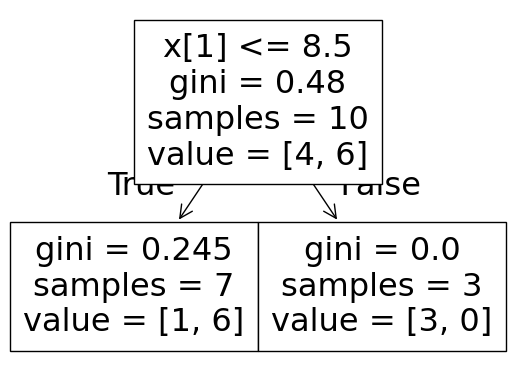

In [171]:
plot_tree(dt2)

<Axes: >

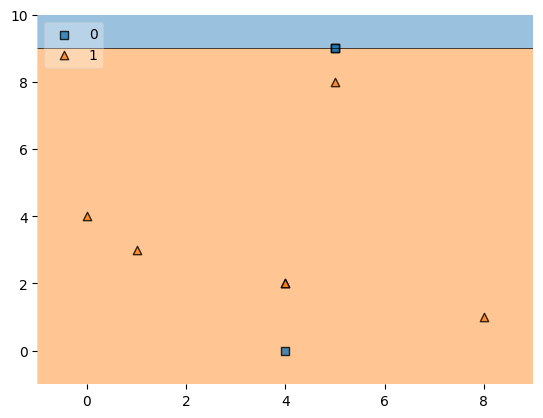

In [172]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [173]:
second_df['y_pred'] = dt2.predict(X)

In [174]:
second_df

,x1,x2,label,weights,y_pred
9,4,0,0,0.1,1
7,8,1,1,0.1,1
1,4,2,1,0.1,1
5,5,8,1,0.1,1
6,5,9,0,0.1,0
8,0,4,1,0.1,1
1,4,2,1,0.1,1
6,5,9,0,0.1,0
0,1,3,1,0.1,1
6,5,9,0,0.1,0


In [175]:
alpha2 = calculate_model_weight(0.2)

In [176]:
alpha2

np.float64(0.6931471805611953)

In [177]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [178]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [179]:
second_df

,x1,x2,label,weights,y_pred,updated_weights
9,4,0,0,0.1,1,0.297427
7,8,1,1,0.1,1,0.033622
1,4,2,1,0.1,1,0.033622
5,5,8,1,0.1,1,0.033622
6,5,9,0,0.1,0,0.033622
8,0,4,1,0.1,1,0.033622
1,4,2,1,0.1,1,0.033622
6,5,9,0,0.1,0,0.033622
0,1,3,1,0.1,1,0.033622
6,5,9,0,0.1,0,0.033622


In [180]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [181]:
second_df

,x1,x2,label,weights,y_pred,updated_weights,nomalized_weights
9,4,0,0,0.1,1,0.297427,0.495694
7,8,1,1,0.1,1,0.033622,0.056034
1,4,2,1,0.1,1,0.033622,0.056034
5,5,8,1,0.1,1,0.033622,0.056034
6,5,9,0,0.1,0,0.033622,0.056034
8,0,4,1,0.1,1,0.033622,0.056034
1,4,2,1,0.1,1,0.033622,0.056034
6,5,9,0,0.1,0,0.033622,0.056034
0,1,3,1,0.1,1,0.033622,0.056034
6,5,9,0,0.1,0,0.033622,0.056034


In [182]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [183]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [184]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [185]:
second_df[['x1','x2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
9,4,0,0,0.1,1,0.495694,0.000000,0.495694
7,8,1,1,0.1,1,0.056034,0.495694,0.551728
1,4,2,1,0.1,1,0.056034,0.551728,0.607762
5,5,8,1,0.1,1,0.056034,0.607762,0.663796
6,5,9,0,0.1,0,0.056034,0.663796,0.719830
8,0,4,1,0.1,1,0.056034,0.719830,0.775864
1,4,2,1,0.1,1,0.056034,0.775864,0.831898
6,5,9,0,0.1,0,0.056034,0.831898,0.887932
0,1,3,1,0.1,1,0.056034,0.887932,0.943966
6,5,9,0,0.1,0,0.056034,0.943966,1.000000


In [186]:
index_values = create_new_dataset(second_df)

In [187]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [188]:
third_df

,x1,x2,label,weights
6,5,9,0,0.1
6,5,9,0,0.1
6,5,9,0,0.1
6,5,9,0,0.1
6,5,9,0,0.1
1,4,2,1,0.1
6,5,9,0,0.1
0,1,3,1,0.1
7,8,1,1,0.1
7,8,1,1,0.1


In [189]:

dt3 = DecisionTreeClassifier(max_depth=1)

X = third_df.iloc[:,0:2].values
y = third_df.iloc[:,2].values

dt3.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: >

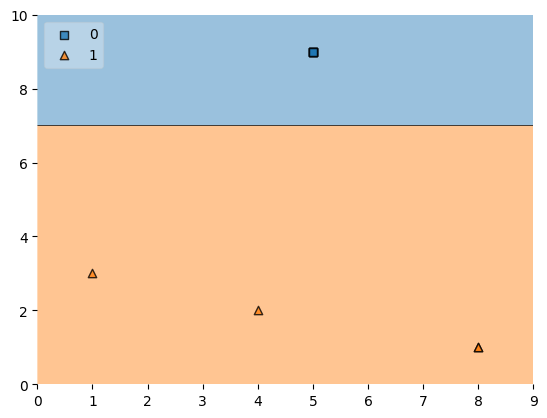

In [190]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [191]:

third_df['y_pred'] = dt3.predict(X)

In [192]:
third_df

,x1,x2,label,weights,y_pred
6,5,9,0,0.1,0
6,5,9,0,0.1,0
6,5,9,0,0.1,0
6,5,9,0,0.1,0
6,5,9,0,0.1,0
1,4,2,1,0.1,1
6,5,9,0,0.1,0
0,1,3,1,0.1,1
7,8,1,1,0.1,1
7,8,1,1,0.1,1


In [193]:
alpha3 = calculate_model_weight(0.00000000000000000000000000000000001)
alpha3

np.float64(40.2952391273958)

In [194]:
print(alpha1,alpha2,alpha3)

0.4236489301957447 0.6931471805611953 40.2952391273958


# prediction

In [195]:

query = np.array([1,5]).reshape(1,2)
dt.predict(query)

array([1])

In [196]:

dt2.predict(query)

array([1])

In [197]:

dt3.predict(query)

array([1])

In [198]:

alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(41.41203523815274)

In [199]:

np.sign(41.41)

np.float64(1.0)

In [201]:

query = np.array([9,9]).reshape(1,2)
dt.predict(query)

array([0])

In [202]:

dt2.predict(query)

array([0])

In [203]:
dt3.predict(query)

array([0])

In [204]:
alpha1*(-1) + alpha2*(-1) + alpha3*(-1)

np.float64(-41.41203523815274)

In [205]:
np.sign(-41.41)

np.float64(-1.0)